# 10 PAE Full Dataset (K=10)

Run the probabilistic archetypal AE with K=12 on the full Levine32 dataset (no downsampling, ~265k cells).
Uses `configs/levine32_pae_k10_full.yaml`: 1 seed, variance_reg_weight=1e-3 to prevent archetype collapse, diversity_reg_weight=5e-3.

In [11]:
from pathlib import Path
import os
import sys
import json

def _find_repo_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for path in candidates:
        if (path / 'pyproject.toml').exists() and (path / 'src' / 'cytof_archetypes').exists():
            return path
    fallback = Path('/Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv')
    if (fallback / 'src' / 'cytof_archetypes').exists():
        return fallback
    raise RuntimeError('Could not locate repository root containing src/cytof_archetypes')

REPO_ROOT = _find_repo_root()
SRC_DIR = REPO_ROOT / 'src'
def _resolve_out_dir() -> Path:
    env = os.environ.get('CYTOF_SUITE_OUTPUT_DIR')
    if env:
        return Path(env)
    cfg_path = REPO_ROOT / 'configs' / 'levine32_pae_k10_full.yaml'
    if cfg_path.exists():
        try:
            import yaml
            cfg = yaml.safe_load(cfg_path.read_text(encoding='utf-8')) or {}
            out_raw = cfg.get('output_dir')
            if out_raw:
                out_path = Path(out_raw)
                return out_path if out_path.is_absolute() else REPO_ROOT / out_path
        except Exception:
            pass
    return REPO_ROOT / 'outputs' / 'K10'

OUT_DIR = _resolve_out_dir()

def _artifact_exists(path: Path) -> bool:
    if path.exists():
        return True
    print(f'Missing artifact: {path}')
    print('Run the suite first: python scripts/run_experiment_suite.py --config configs/levine32_pae_k10_full.yaml')
    return False
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
print('Repo root:', REPO_ROOT)
print('Using src dir:', SRC_DIR)
print('Using suite output dir:', OUT_DIR)


Repo root: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv
Using src dir: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/src
Using suite output dir: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/pae_k10_full


In [12]:
from pathlib import Path
import os
import time

from cytof_archetypes.experiments import load_suite_config, run_experiment_suite

CONFIG_PATH = REPO_ROOT / 'configs' / 'levine32_pae_k10_full.yaml'
assert CONFIG_PATH.exists(), f'Missing config: {CONFIG_PATH}'
print('Using config:', CONFIG_PATH)

# Optional: override output dir without editing YAML.
# os.environ['CYTOF_SUITE_OUTPUT_DIR'] = str(REPO_ROOT / 'outputs' / 'experiment_suite')

Using config: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/configs/levine32_pae_k10_full.yaml


In [13]:
cfg = load_suite_config(CONFIG_PATH)
env_out = os.environ.get('CYTOF_SUITE_OUTPUT_DIR')
if env_out:
    cfg['output_dir'] = env_out

# No downsampling — config already has none, but enforce it defensively
# cfg.setdefault('dataset', {}).pop('downsample_factor', None)
# cfg.setdefault('dataset', {}).pop('downsample_fraction', None)

# Enable live loss plot in the notebook (no-op when running headless on RunPod)
cfg['show_progress'] = True
cfg['show_run_logs'] = True
cfg['show_training_progress'] = True
pae_cfg = cfg.setdefault('methods', {}).setdefault('probabilistic_archetypal_ae', {})
pae_cfg['live_loss_plot'] = True
pae_cfg['show_training_progress'] = True

print('Resolved output_dir:', cfg['output_dir'])
print('Dataset:', cfg.get('dataset', {}).get('input_path'))
print('Downsample factor:', cfg.get('dataset', {}).get('downsample_factor', 'none'))
print('Seeds:', cfg.get('seeds', []))
print('K sweep:', cfg.get('sweeps', {}).get('k_values', []))
print('live_loss_plot:', pae_cfg.get('live_loss_plot'))


Resolved output_dir: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/pae_k10_full
Dataset: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/data/levine32_processed.h5ad
Downsample factor: none
Seeds: [13]
K sweep: [12]
live_loss_plot: True


In [14]:
cfg

{'seed': 42,
 'output_dir': '/Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/pae_k10_full',
 'notebook_output_dir': '/Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/notebooks/experiment_suite',
 'show_progress': True,
 'show_run_logs': True,
 'show_training_progress': True,
 'training_progress_level': 'epoch',
 'training_progress_leave': False,
 'cpu_multiprocessing_workers': 1,
 'cpu_parallel_methods': [],
 'gpu_multiprocessing_workers': 1,
 'gpu_parallel_methods': ['probabilistic_archetypal_ae'],
 'device': 'auto',
 'dataset': {'name': 'levine32',
  'input_path': '/Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/data/levine32_processed.h5ad',
  'marker_columns': None,
  'label_column': 'label',
  'cell_id_column': 'cell_id',
  'val_fraction': 0.15,
  'test_fraction': 0.15},
 'preprocessing': {'transform': 'none',
  'arcsinh_cofactor': 5.0,
  'normalization': 'zscore',
  'clip_min': None,
  'clip_max': None},
 'seeds': [13],
 'sweeps': {'k_value

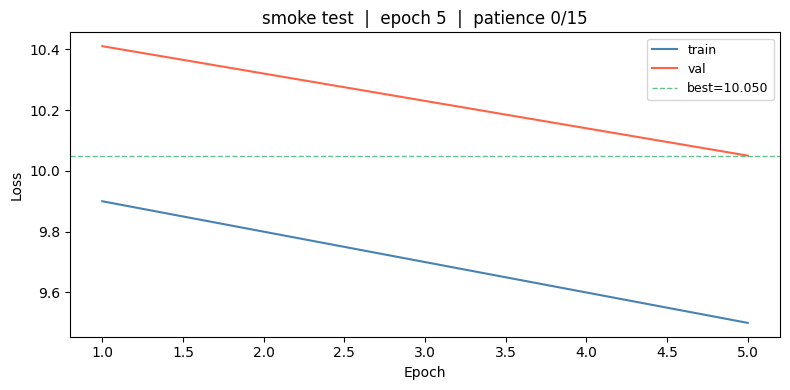

Live plot OK


In [15]:
# Smoke-test: verify the live plot mechanism works before the full run
%matplotlib inline
import sys; sys.path.insert(0, str(REPO_ROOT / 'src'))
from cytof_archetypes.baselines.neural import _make_live_plot, _update_live_plot
import numpy as np

_fig, _ax, _fns = _make_live_plot('smoke test — should appear below')
if _fig is None:
    print('WARNING: live plot setup failed — check matplotlib/IPython install')
else:
    fake_rows = [{'epoch': e, 'train_loss': 10 - e*0.1, 'val_loss': 10.5 - e*0.09} for e in range(1, 6)]
    _update_live_plot(_fig, _ax, _fns, fake_rows, best_val=fake_rows[-1]['val_loss'],
                      patience_counter=0, patience=15, desc='smoke test')
    print('Live plot OK')


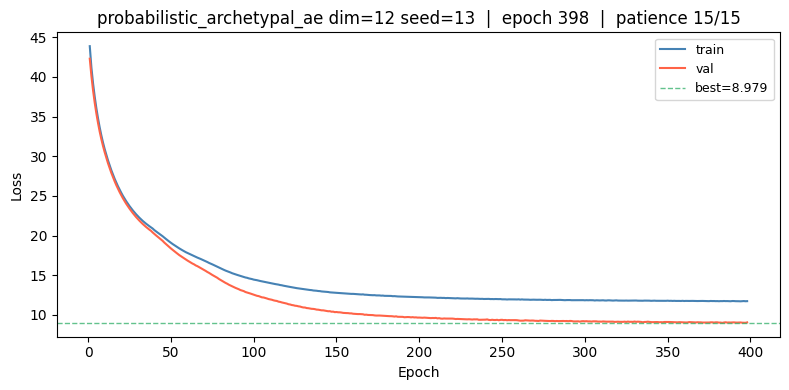

[core-run 1/1] DONE  method=probabilistic_archetypal_ae dim=12 seed=13 val_mse=0.614843 test_mse=0.613590 elapsed=827.0s
[accel-stage 1/1] method=probabilistic_archetypal_ae dim=12 seed=13
[suite-phase] 3/12: run_fit_vs_complexity
[suite-phase] 4/12: run_deconvolution_quality


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[suite-phase] 5/12: run_deterministic_vs_probabilistic


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[suite-phase] 6/12: run_k_selection
[suite-phase] 7/12: run_component_biology
[suite-phase] 8/12: run_rare_population_preservation
[suite-phase] 9/12: run_secondary_dataset_validation
[suite-phase] 10/12: run_auxiliary_representation_models
[suite-phase] 11/12: run_interpretability_tradeoff
[suite-phase] 12/12: generate_benchmark_notebooks -> /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/notebooks/experiment_suite
Completed full suite in 14.49 minutes
Output directory: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/pae_k10_full


In [16]:
RUN_FULL = True  # set to False to skip execution
if RUN_FULL:
    t0 = time.time()
    out_dir = run_experiment_suite(cfg)
    dt = time.time() - t0
    print(f'Completed full suite in {dt/60:.2f} minutes')
    print('Output directory:', out_dir)
else:
    out_dir = Path(cfg['output_dir'])
    print('Execution skipped. Expected output directory:', out_dir)

In [17]:
import pandas as pd

out_dir = Path(cfg['output_dir'])
tables_dir = out_dir / 'tables'
reports_dir = out_dir / 'reports'
plots_dir = out_dir / 'plots'

required_tables = [
    'fit_vs_complexity_summary.csv',
    'deconvolution_quality_summary.csv',
    'component_marker_profiles.csv',
    'component_marker_enrichment.csv',
    'deterministic_vs_probabilistic_summary.csv',
    'per_class_method_metrics.csv',
    'fit_vs_interpretability.csv',
    'k_selection_summary.csv',
    'class_component_means.csv',
    'per_cell_weight_entropy.csv',
]

status = []
for name in required_tables:
    path = tables_dir / name
    status.append({'table': name, 'exists': path.exists(), 'path': str(path)})
status_df = pd.DataFrame(status)
display(status_df)
print('All required tables present:', bool(status_df['exists'].all()))

,table,exists,path
0,fit_vs_complexity_summary.csv,True,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/P...
1,deconvolution_quality_summary.csv,True,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/P...
2,component_marker_profiles.csv,True,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/P...
3,component_marker_enrichment.csv,True,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/P...
4,deterministic_vs_probabilistic_summary.csv,True,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/P...
5,per_class_method_metrics.csv,True,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/P...
6,fit_vs_interpretability.csv,True,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/P...
7,k_selection_summary.csv,True,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/P...
8,class_component_means.csv,True,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/P...
9,per_cell_weight_entropy.csv,True,/Users/ronguy/Dropbox/Work/CyTOF/Experiments/P...


All required tables present: True


In [18]:
manifest_path = reports_dir / 'artifact_manifest.json'
if manifest_path.exists():
    import json
    manifest = json.loads(manifest_path.read_text(encoding='utf-8'))
    print('Manifest summary keys:', sorted(manifest.keys()))
    print('Number of tables:', len(manifest.get('tables', [])))
    print('Number of plots:', len(manifest.get('plots', [])))
else:
    print('Missing artifact manifest:', manifest_path)

Manifest summary keys: ['has_auxiliary_results', 'has_secondary_dataset_results', 'n_component_profile_rows', 'n_deconvolution_rows', 'n_enrichment_rows', 'n_k_selection_rows', 'n_rare_rows', 'notebook_output_dir', 'notebooks', 'plots', 'tables']
Number of tables: 13
Number of plots: 17


In [19]:
k_path = tables_dir / 'k_selection_summary.csv'
if k_path.exists():
    k_df = pd.read_csv(k_path)
    display(k_df.sort_values(['method', 'k']).head(30))
else:
    print('Missing:', k_path)

,method,k,seed,val_mse,test_mse,rare_class_error,interpretability_score,component_redundancy,fit_score,rare_score,interp_score,redundancy_score,k_selection_score,recommended_k
0,probabilistic_archetypal_ae,12,13.0,0.614843,0.61359,0.822594,0.550926,0.118688,0.0,0.0,1.0,0.0,0.25,12
